In [ ]:
from shot_processing import *
from lightfield_processing import * 
from pathlib import Path
import hashlib
import csv 
import re
import sys
import json
import ast
import numpy as np
import h5py
import spe2py as spe
import scipy.io
import matplotlib.pyplot as plt

In [3]:
import MDSplus as mds
c = mds.Connection('172.25.35.142')
c.get("getenv('zaphd_path')")
c.openTree('zaphd',250423006)
v_c = np.array(c.get(r'\v_compress'))
print(np.max(np.abs(v_c)))
v_a = np.array(c.get(r'\v_accel'))
print(np.max(np.abs(v_a)))

5835.78205704689
2144.95647251606


In [13]:
from MDSplus import Connection

c = Connection("172.25.35.142") # or whatever host/port you use
c.openTree("zaphd", 250423010)


paths = c.get("getnci('***','FULLPATH')") # returns an array of full node paths
for p in paths:
    print(str(p))

\ZAPHD::TOP:BASELINE_SN                                                        
\ZAPHD::TOP:COMMENT                                                            
\ZAPHD::TOP.ACTIONS                                                            
\ZAPHD::TOP.ANALYSISHD                                                         
\ZAPHD::TOP.CALIBRATION                                                        
\ZAPHD::TOP.DIGITIZERSHD                                                       
\ZAPHD::TOP.PARAMETERS                                                         
\ZAPHD::TOP.SIGNALS                                                            
\ZAPHD::TOP.SVN                                                                
\ZAPHD::TOP.TRIGGERS                                                           
\ZAPHD::TOP.ACTIONS:END_OF_INIT                                                
\ZAPHD::TOP.ACTIONS:END_OF_STORE                                               
\ZAPHD::TOP.ANALYSISHD.DHIHD            

In [3]:
clear_manifest()

Removed manifest: curated/manifest.csv
Created empty manifest with header: curated/manifest.csv


In [ ]:
c = mds.Connection('172.25.35.142')
c.get("getenv('zaphd_path')")

In [ ]:
new_count = 0
skipped_files = []
files_scanned = 0
files_already_ingested = 0
files_valid_id = 0

ingested = load_manifest()
f = open_h5()

for raw_dir in RAW_DIR:
    for spe in raw_dir.rglob("*.spe"):
        files_scanned += 1
        shot_id = parse_shot_id(spe)
        
        if not shot_id:
            continue
        else:
            files_valid_id += 1

        # Use consistent normalization for manifest comparison
        shot_id_str = normalize_shot_id_for_comparison(shot_id)
        
        if shot_id_str in ingested:
            files_already_ingested += 1
            continue

        # Convert shot_id to string representation for comparison with manifest
        if isinstance(shot_id, (list, tuple)):
            shot_id_str = str(shot_id)  # This will create "('250219', '17')" format
        else:
            shot_id_str = str(shot_id)
        
        if shot_id_str in ingested:
            files_already_ingested += 1
            continue

        try:
            img, meta = read_spe(spe)
        except UnicodeDecodeError as e:
            print(f"Skipping {spe} (UnicodeDecodeError): {e}")
            skipped_files.append((str(spe), "UnicodeDecodeError", str(e)))
            continue
        except Exception as e:
            print(f"Skipping {spe} (read error: {type(e).__name__}): {e}")
            skipped_files.append((str(spe), type(e).__name__, str(e)))
            continue

        raw_md5 = md5sum(spe)
        hdf5_key = str(shot_id)
        write_fiber_dataset(f, shot_id, img, meta, raw_md5)
        H, W = int(img.shape[0]), int(img.shape[1])
        append_manifest_row({
            "shot_id": shot_id_str,  # Use the string version for consistency
            "raw_path": str(spe).replace("\\", "/"),
            "raw_md5": raw_md5,
            "H": H,
            "W": W
        })
        new_count += 1

print(f"PROCESSING SUMMARY:")
print(f"  Files scanned: {files_scanned}")
print(f"  Files already ingested: {files_already_ingested}")
print(f"  Files with errors: {len(skipped_files)}")
print(f"  Files with valid IDs: {files_valid_id}")
print(f"  New files ingested: {new_count}")
print(f"  Total in manifest: {len(ingested) + new_count}")

XML Footer was not loaded prior to calling _get_wavelength or 
XML Footer does not contain Wavelength Mapping information
Successfully loaded 1 file(s) in a SpeFile object
XML Footer was not loaded prior to calling _get_wavelength or 
XML Footer does not contain Wavelength Mapping information
Successfully loaded 1 file(s) in a SpeFile object
XML Footer was not loaded prior to calling _get_wavelength or 
XML Footer does not contain Wavelength Mapping information
Successfully loaded 1 file(s) in a SpeFile object
XML Footer was not loaded prior to calling _get_wavelength or 
XML Footer does not contain Wavelength Mapping information
Successfully loaded 1 file(s) in a SpeFile object
XML Footer was not loaded prior to calling _get_wavelength or 
XML Footer does not contain Wavelength Mapping information
Successfully loaded 1 file(s) in a SpeFile object
XML Footer was not loaded prior to calling _get_wavelength or 
XML Footer does not contain Wavelength Mapping information
Successfully loade

In [ ]:
OUT_H5 = "/Users/elyselian/Downloads/Python Code/S_XB/sxb_analysis/curated/experiment.h5" 

profiles = []     # will collect each shot’s middle column
shot_names = []   # record shot keys for later metadata writing

with h5py.File(OUT_H5, "r") as f:
    shots_grp = f.get("shots")
    if shots_grp is None:
        raise RuntimeError("No 'shots' group found in the HDF5 file.")

    for shot_key, grp in shots_grp.items():
        dset = grp.get("image")
        if dset is None:
            # fallback: first dataset in group
            dset = next((grp[name] for name in grp if isinstance(grp[name], h5py.Dataset)), None)
        if dset is None:
            continue

        img = dset[()]             # load as numpy array
        H, W = img.shape
        col_idx = W // 2           # pick middle column
        col = img[:, col_idx].astype(np.float32)

        profiles.append(col)
        shot_names.append(shot_key)

# Stack into 2D array: shape = (N_shots, N_pixels)
profiles = np.stack(profiles, axis=0)

print(f"Loaded {len(shot_names)} shots.")
print("profiles array shape:", profiles.shape)

Loaded 434 shots.
profiles array shape: (434, 1024)


Manifest row at index 52:
{'shot_id': "('250424', '023')", 'raw_path': '/Users/elyselian/Library/CloudStorage/GoogleDrive-elyse16@uw.edu/Shared drives/Shumlak Lab/Diagnostics/Spectroscopy/S_XB/Data/Ops/250424/250424  023.spe', 'raw_md5': '4b9bc951f965eb0245cd1bbabc7fa969', 'H': '1024', 'W': '1024'}

Group attributes:
  avg_irradiance: [7.52420980e+10 4.80472347e+10 4.29831702e+10 3.58975803e+10
 3.38983665e+10 2.84075912e+10 2.78373681e+10 2.30644888e+10
 2.82650805e+10 2.86973906e+10 2.55236527e+10 2.55313979e+10
 2.60522276e+10 2.59213997e+10 2.56206335e+10 2.40550790e+10
 2.53449444e+10 2.83341738e+10 3.08299048e+10 3.05099372e+10]
  avg_irradiance_units: W/m^2
  avg_photon_flux_gate_ns: 50.0
  inner_shell_emissivity: 8.176241763664438e+26
  inner_shell_emissivity_units: a.u.
  peak_heights: [1.0925831e+30 6.9768915e+29 6.2415438e+29 5.2126524e+29 4.9223485e+29
 4.1250381e+29 4.0422369e+29 3.3491718e+29 4.1043443e+29 4.1671197e+29
 3.7062643e+29 3.7073890e+29 3.7830183e+29 3.7640208

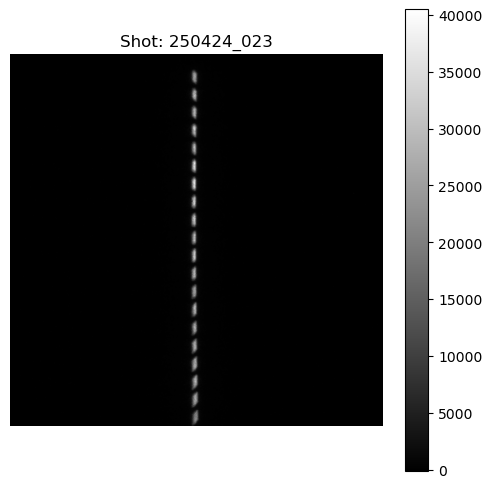

In [ ]:

with MANIFEST.open("r") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

target_index = 54-2
row = rows[target_index]

if not row:
    print("Manifest is empty.")
else:
    print(f"Manifest row at index {target_index}:")
    print(row)
    raw_shot = row.get("shot_id")
    try:
        shot_key = ast.literal_eval(raw_shot)
    except Exception:
        shot_key = raw_shot
    if isinstance(shot_key, (list, tuple)):
        group_key = "_".join(map(str, shot_key))
    else:
        group_key = str(shot_key)
    with h5py.File(OUT_H5, "r") as hf:
        grp = hf.get(f"shots/{group_key}")
        if grp is None:
            print(f"Group shots/{group_key} not found in {OUT_H5}")
        else:
            print("\nGroup attributes:")
            for k, v in grp.attrs.items():
                val = v.decode() if isinstance(v, (bytes, bytearray)) else v
                try:
                    if isinstance(val, str):
                        val = json.loads(val)
                except Exception:
                    pass
                print(f"  {k}: {val}")
            dset = grp.get("image")
            if dset is None:
                dset = next((grp[name] for name in grp if isinstance(grp[name], h5py.Dataset)), None)

            if dset is None:
                print("No dataset found under group.")
            else:
                print("\nDataset attributes:")
                for k, v in dset.attrs.items():
                    val = v.decode() if isinstance(v, (bytes, bytearray)) else v
                    try:
                        if isinstance(val, str):
                            val = json.loads(val)
                    except Exception:
                        pass
                    print(f"  {k}: {val}")

                img = dset[()]
                print("\nImage shape:", img.shape, "dtype:", img.dtype)

                plt.figure(figsize=(6,6))
                plt.imshow(img, cmap="gray", origin="lower")
                plt.title(f"Shot: {group_key}")
                plt.axis("off")
                plt.colorbar()
                plt.show()

In [30]:
import numpy as np
import h5py, scipy.io, re
from pathlib import Path
from skimage.filters import threshold_local
from skimage import morphology
from shot_processing import *

OUT_H5 = Path("/Users/elyselian/Downloads/Python Code/S_XB/sxb_analysis/curated/experiment.h5")

def _parse_gate_ns(grp, dset=None):
    raw = grp.attrs.get("Gate Width (ns)")
    if raw is None and dset is not None:
        raw = dset.attrs.get("Gate Width (ns)")
    if raw is None:
        raise KeyError("Gate Width (ns) not found on group or dataset")
    if isinstance(raw, (bytes, bytearray)):
        s = raw.decode("utf-8", "ignore")
    elif hasattr(raw, "item"):
        try:
            s = raw.item()
        except Exception:
            s = str(raw)
    else:
        s = raw
    if isinstance(s, (int, float)):
        return float(s)
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(s))
    return float(m.group(0)) if m else float(s)

def compute_average_irradiance_per_fiber(image, fibers, exposure_ns,
                                         gate_reference_s=20.999,
                                         wavelength_nm=229.7):
    """Compute average irradiance and photon flux per fiber region.

    This simplified version removes any active pixel thresholding/overlay.
    Each fiber's bounding box is cropped; irradiance scaling using
    irradiancepcount (per-column) is applied; the mean over the entire
    cropped region is taken. If irradiancepcount is a scalar it is
    broadcast; if its length differs from the crop width it is linearly
    interpolated.

    Parameters
    ----------
    image : 2D ndarray
        Shot image (counts).
    fibers : sequence
        Fiber structs (MATLAB structs or dicts) each with BoundingBox and
        optionally irradiancepcount.
    exposure_ns : float
        Gate width in nanoseconds.
    gate_reference_s : float, optional
        Reference scaling constant (seconds); retained from earlier code.
    wavelength_nm : float, optional
        Wavelength for photon energy conversion.

    Returns
    -------
    avgI : ndarray (N,)
        Average irradiance per fiber (arbitrary units scaled by gate reference).
    photonFlux : ndarray (N,)
        Photon flux per fiber (photons / m^2 / s).
    """
    H, W = image.shape
    N = len(fibers)
    avgI = np.zeros(N, dtype=float)
    gate_ratio = gate_reference_s / (exposure_ns * 1e-9)

    def _bbox(vals):
        if vals is None:
            return 1.0, 1.0, float(W), float(H)
        flat = np.asarray(vals, dtype=object).ravel()
        if flat.size < 4:
            return 1.0, 1.0, float(W), float(H)
        def _f(v):
            while isinstance(v, (np.ndarray, list, tuple)) and np.size(v) == 1:
                v = np.asarray(v, dtype=object).ravel()[0]
            try:
                return float(v)
            except Exception:
                return float(np.asarray(v, dtype=float).ravel()[0])
        return tuple(_f(x) for x in flat[:4])

    for i, fiber in enumerate(fibers):
        bbox = None
        if hasattr(fiber, 'BoundingBox'):
            bbox = getattr(fiber, 'BoundingBox')
        elif isinstance(fiber, dict) and 'BoundingBox' in fiber:
            bbox = fiber['BoundingBox']
        x1f, y1f, wboxf, hboxf = _bbox(bbox)
        x1 = max(0, int(round(x1f)) - 1)
        y1 = max(0, int(round(y1f)) - 1)
        wbox = int(round(wboxf))
        hbox = int(round(hboxf))
        x2 = min(W, x1 + wbox)
        y2 = min(H, y1 + hbox)
        if (x1 >= x2) or (y1 >= y2):
            avgI[i] = 0.0
            continue
        crop = image[y1:y2, x1:x2]
        hbox = crop.shape[0]
        wbox = crop.shape[1]

        irr_pc = getattr(fiber, 'irradiancepcount', None)
        if irr_pc is None and isinstance(fiber, dict):
            irr_pc = fiber.get('irradiancepcount', 1.0)
        if irr_pc is None:
            irr_pc = 1.0
        arr_pc = np.asarray(irr_pc).reshape(-1)
        if arr_pc.size == 1:
            arr_pc = np.full(wbox, float(arr_pc.ravel()[0]))
        elif arr_pc.size != wbox:
            xp = np.linspace(0, 1, arr_pc.size)
            xq = np.linspace(0, 1, wbox)
            arr_pc = np.interp(xq, xp, arr_pc.astype(float))
        scale = np.tile(arr_pc.reshape(1, -1), (hbox, 1))
        irr = gate_ratio * crop * scale
        avgI[i] = irr.mean() if irr.size else 0.0

    h = 6.62607015e-34
    c = 3e8
    lam_m = wavelength_nm * 1e-9
    photonFlux = 4 * np.pi * avgI / (h * c / lam_m)
    return avgI, photonFlux

###############################################################
# Strict 20-peak extraction from a middle column
###############################################################
def extract_20_peaks_middle_column(image, smooth_window=12, min_distance=35,
                                   start_mult=0.6, max_iter=40, allow_trim=True):
    """Return exactly 20 peak intensities along the middle column.

    Adaptive threshold lowers until >=20 peaks found. If more than 20 peaks
    are present and *allow_trim* is True, the tallest 20 are selected and
    then reordered by spatial position.

    Returns
    -------
    intensities : ndarray shape (20,) or None if cannot find 20.
    peaks_idx   : ndarray of peak indices (after spatial ordering) or None.
    """
    from scipy.signal import find_peaks
    H, W = image.shape
    col_idx = W // 2
    col = image[:, col_idx].astype(float)
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        col_smooth = np.convolve(col, kernel, mode='same')
    else:
        col_smooth = col

    multiplication = start_mult
    peaks, props = [], {}
    for it in range(max_iter):
        height_thresh = col_smooth.mean() - multiplication * col_smooth.std()
        peaks, props = find_peaks(col_smooth, distance=min_distance, height=height_thresh)
        if len(peaks) == 20:
            break
        if len(peaks) > 20 and allow_trim:
            break  # will trim after loop
        multiplication += 0.1  # lower threshold progressively

    if len(peaks) < 20:
        return None, None

    peak_heights = props.get('peak_heights', col_smooth[peaks])
    if len(peaks) > 20:
        top_idx_global = np.argsort(peak_heights)[-20:]
        peaks_20 = peaks[top_idx_global]
        heights_20 = peak_heights[top_idx_global]
    else:
        peaks_20 = peaks
        heights_20 = peak_heights

    # reorder by spatial position
    order = np.argsort(peaks_20)
    peaks_sorted = peaks_20[order]
    intensities = heights_20[order]
    return intensities.astype(float), peaks_sorted.astype(int)


# ---- load fibers once ----
try:
    fibers
except NameError:
    mat = scipy.io.loadmat(
        "/Users/elyselian/Library/CloudStorage/GoogleDrive-elyse16@uw.edu/Shared drives/Shumlak Lab/Diagnostics/Spectroscopy/S_XB/Code/fiber_regions.mat",
        squeeze_me=True,
        struct_as_record=False,
    )
    fibers = mat["fibers"]

# ---- main loop (start included) ----
processed = 0
skipped = 0
errors = 0

with h5py.File(OUT_H5, "a") as f:
    shots_grp = f["shots"]
    for shot_key, grp in shots_grp.items():
        dset = grp.get("image") or next((grp[n] for n in grp if isinstance(grp[n], h5py.Dataset)), None)
        if dset is None:
            skipped += 1
            continue
        try:
            img = dset[()]
            if img.ndim > 2:
                img = np.squeeze(img)
            gate_ns = _parse_gate_ns(grp, dset)
            avgI, photonFlux = compute_average_irradiance_per_fiber(img, fibers, exposure_ns=gate_ns)

            # store arrays as metadata on the group
            grp.attrs["avg_irradiance"] = np.asarray(avgI, dtype=np.float64)
            grp.attrs["photon_flux"] = np.asarray(photonFlux, dtype=np.float64)
            grp.attrs["avg_irradiance_units"] = "W/m^2"
            grp.attrs["photon_flux_units"] = "photons/m^2/s"
            grp.attrs["avg_photon_flux_gate_ns"] = float(gate_ns)

            processed += 1
            if processed % 10 == 0:
                print(f"Processed {processed} shots...")
        except Exception as e:
            errors += 1
            print(f"[{shot_key}] error: {type(e).__name__}: {e}")

print(f"Done. Processed={processed}, Skipped={skipped}, Errors={errors}")

Processed 10 shots...
Processed 20 shots...
Processed 30 shots...
Processed 40 shots...
Processed 50 shots...
Processed 60 shots...
Processed 70 shots...
Processed 80 shots...
Processed 90 shots...
Processed 100 shots...
Processed 110 shots...
Processed 120 shots...
Processed 130 shots...
Processed 140 shots...
Processed 150 shots...
Processed 160 shots...
Processed 170 shots...
Processed 180 shots...
Processed 190 shots...
Processed 200 shots...
Processed 210 shots...
Processed 220 shots...
Processed 230 shots...
Processed 240 shots...
Processed 250 shots...
Processed 260 shots...
Processed 270 shots...
Processed 280 shots...
Processed 290 shots...
Processed 300 shots...
Processed 310 shots...
Processed 320 shots...
Processed 330 shots...
Processed 340 shots...
Processed 350 shots...
Processed 360 shots...
Processed 370 shots...
Processed 380 shots...
Processed 390 shots...
Processed 400 shots...
Processed 410 shots...
Processed 420 shots...
Processed 430 shots...
Done. Processed=434,

middle column index: 512
found peaks: 20
  peak 0: row=34, value=55558.667
  peak 1: row=73, value=47216.167
  peak 2: row=122, value=39015.917
  peak 3: row=168, value=27533.167
  peak 4: row=216, value=20498.417
  peak 5: row=271, value=17934.750
  peak 6: row=319, value=15389.333
  peak 7: row=367, value=13658.250
  peak 8: row=414, value=11421.750
  peak 9: row=465, value=10522.333
  peak 10: row=522, value=8963.500
  peak 11: row=566, value=7947.083
  peak 12: row=617, value=7226.250
  peak 13: row=665, value=7914.667
  peak 14: row=717, value=8575.417
  peak 15: row=759, value=7902.833
  peak 16: row=817, value=12570.000
  peak 17: row=863, value=9703.833
  peak 18: row=909, value=10310.167
  peak 19: row=962, value=12458.667


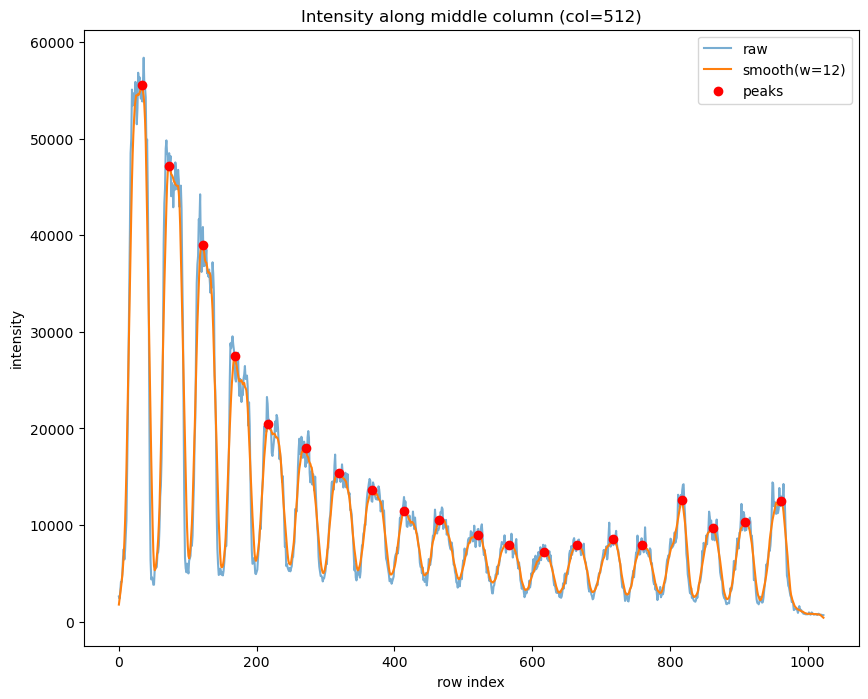

In [44]:
# find peaks in the middle column and plot
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# get middle column
H, W = img.shape
col_idx = W // 2
col = img[:, col_idx].astype(float)

# optional smoothing (moving average)
smooth_window = 12
if smooth_window > 1:
    kernel = np.ones(smooth_window) / smooth_window
    col_smooth = np.convolve(col, kernel, mode="same")
else:
    col_smooth = col

# peak detection parameters (adjust if needed)
min_distance = 35     # minimum row separation between peaks
height_thresh = col_smooth.mean() - 0.7 * col_smooth.std()  # threshold for peak prominence

peaks, props = find_peaks(col_smooth, distance=min_distance, height=height_thresh)

# print peak info
print("middle column index:", col_idx)
print("found peaks:", len(peaks))
chord_measured = []
for i, p in enumerate(peaks):
    h = props["peak_heights"][i] if "peak_heights" in props else col_smooth[p]
    print(f"  peak {i}: row={p}, value={h:.3f}")
    chord_measured.append(h)

# plot
plt.figure(figsize=(10,8))
rows = np.arange(H)
plt.plot(col, label="raw", alpha=0.6)
plt.plot(col_smooth, label=f"smooth(w={smooth_window})", linewidth=1.5)
plt.scatter(peaks, col_smooth[peaks], color="red", zorder=5, label="peaks")
plt.xlabel("row index")
plt.ylabel("intensity")
plt.title(f"Intensity along middle column (col={col_idx})")
plt.legend()
plt.show()

Inversion date filter active. Including dates: ['250219', '250416', '250423', '250424', '250428', '250514', '250609']
Profile filter: ['hollow']


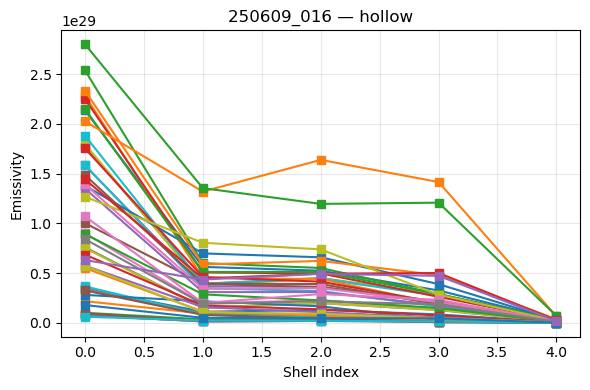

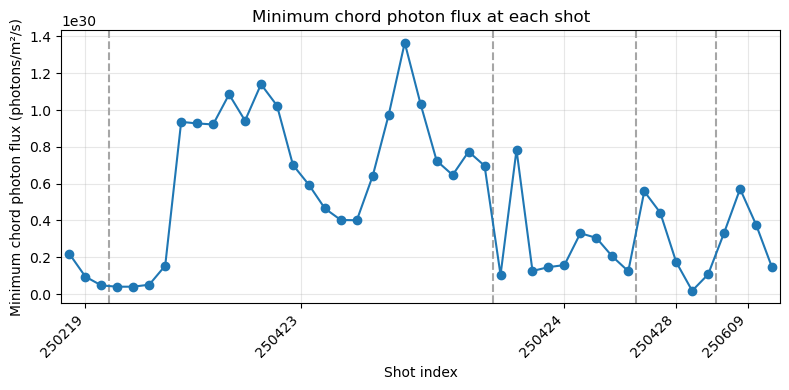

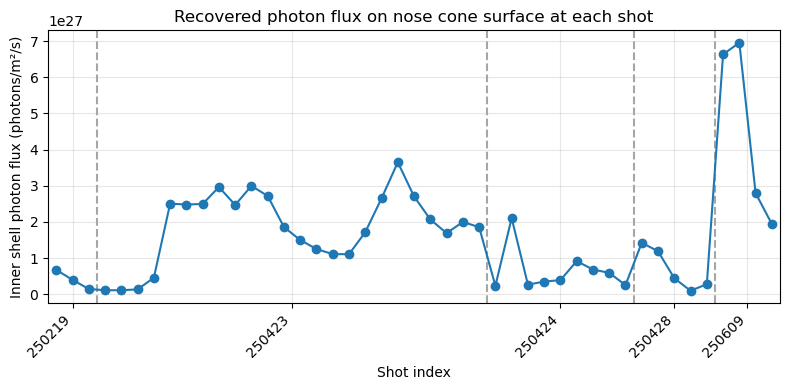

In [41]:
OUT_H5 = Path("/Users/elyselian/Downloads/Python Code/S_XB/sxb_analysis/curated/experiment.h5")

# -------------------------------------------------------------------
# Inversion parameters
lam = 1e-2
w_inner = 2e3
R = 12.42
elec_rad = 7.0
N_shells = 5

# Sort helper: "250424_019" or "250424 019" -> (250424, 19)
import re

def shot_sort_key(name: str):
    m = re.match(r"^(\d{6})\D+(\d+)$", name)
    if m:
        return (int(m.group(1)), int(m.group(2)))
    nums = [int(x) for x in re.findall(r"\d+", name)]
    return (nums[0], nums[1] if len(nums) > 1 else -1) if nums else (999999, 1<<30)

# -------------------------------------------------------------------
# Date filter (reuse if previously defined; else define a placeholder list)
include_dates = ["250219", "250416", "250423", "250424", "250428", "250514", "250609"]  # fallback
include_set = set(include_dates)
print("Inversion date filter active. Including dates:", sorted(include_set))

# Optional profile filter: set to a list of allowed labels, or None to include all
include_profiles = ["hollow"]  # None -> include all profiles
print("Profile filter:", ("ALL" if include_profiles is None else sorted(include_profiles)))

# Helper to extract the leading 6-digit date from a shot key
def shot_date(key: str) -> str:
    m = re.match(r"^(\d{6})", key)
    return m.group(1) if m else ""

# Helper to get a string attribute robustly (handles bytes)
def get_str_attr(grp, key: str, default: str = "") -> str:
    val = grp.attrs.get(key, default)
    if isinstance(val, (bytes, bytearray)):
        try:
            return val.decode("utf-8", "ignore")
        except Exception:
            return default
    return str(val) if val is not None else default

# -------------------------------------------------------------------
# Collect shots (restricted by date and optional profile) and process in date order
results = []
shot_seq = []
dates = []
chord_minima = []  # per-shot min(chord_measured)
written = 0        # count of attrs written
skipped_profile = 0
skipped_len = 0

with h5py.File(OUT_H5, "a") as f:
    shots_grp = f["shots"]

    def allowed_by_profile(grp) -> bool:
        if include_profiles is None:
            return True
        prof = get_str_attr(grp, "profile_shape", "")
        return prof in set(include_profiles)

    # Apply date + optional profile filter
    candidates = [k for k, grp in shots_grp.items() if (shot_date(k) in include_set) and allowed_by_profile(grp)]

    all_shots = sorted(candidates, key=shot_sort_key)

    plt.figure(figsize=(6, 4))

    for shot_key in all_shots:
        grp = shots_grp[shot_key]

        # Choose the 20-length chord vector: prefer peak_heights, else photon_flux
        chord_vec = None
        if "peak_heights" in grp.attrs:
            try:
                chord_vec = np.asarray(grp.attrs["peak_heights"], dtype=float)
            except Exception:
                chord_vec = None
        if chord_vec is None and "photon_flux" in grp.attrs:
            try:
                chord_vec = np.asarray(grp.attrs["photon_flux"], dtype=float)
            except Exception:
                chord_vec = None
        if chord_vec is None or chord_vec.size != 20:
            skipped_len += 1
            continue

        # track min chord intensity for plot context
        min_val = float(np.nanmin(chord_vec))

        # build right-half 10-chord vector for inversion (mirror right side)
        b_raw = np.linspace(11.8, 0, 10)
        I_left = chord_vec[:10]
        I_right = np.flip(chord_vec[10:])
        I_avg = 0.5 * (I_left + I_right)

        eps_rec, (L, edges, b_abs, I_synth, edges2) = prepare_and_peel(
            b_raw, I_right, lam=lam, w_inner=w_inner,
            R=R, elec_rad=elec_rad, N_shells=N_shells,
            inner_chord_num=0, use_tikhonov=True,
            use_synthetic=False, eps_input=None,
        )
        if np.count_nonzero(eps_rec == 0) > 0:
            continue

        inner_shell_val = float(eps_rec[-1])
        grp.attrs["inner_shell_emissivity"] = inner_shell_val
        grp.attrs["inner_shell_emissivity_units"] = "a.u."
        written += 1

        results.append(inner_shell_val)
        chord_minima.append(min_val)
        shot_seq.append(shot_key)
        dates.append(shot_date(shot_key))

        prof = get_str_attr(grp, "profile_shape", "")
        plt.plot(eps_rec, "s-")
        plt.title(f"{shot_key} — {prof}")
        plt.xlabel("Shell index"); plt.ylabel("Emissivity")
        plt.grid(True, alpha=0.3); plt.tight_layout()

plt.show()

# -------------------------------------------------------------------
# Innermost-shell emissivity with date switch markers/labels and min(chord) overlay
fig, ax = plt.subplots(figsize=(8, 4))
y = np.asarray(results)
y_min = np.asarray(chord_minima)
x = np.arange(len(y))

line_eps, = ax.plot(x, y_min, "o-", lw=1.5)
ax.set_xlim(-0.5, len(y) - 0.5)
ax.set_xlabel("Shot index")
ax.set_ylabel("Minimum chord photon flux (photons/m²/s)")
ax.set_title("Minimum chord photon flux at each shot")

bounds = [0]
for i in range(1, len(dates)):
    if dates[i] != dates[i-1]:
        bounds.append(i)
bounds.append(len(dates))

for b in bounds[1:-1]:
    ax.axvline(b - 0.5, color="k", linestyle="--", alpha=0.35, zorder=0)

centers = [0.5 * (bounds[i] + bounds[i+1] - 1) for i in range(len(bounds) - 1)]
labels = [dates[bounds[i]] for i in range(len(bounds) - 1)]
ax.set_xticks(centers)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 4))

line_eps, = ax.plot(x, y, "o-", lw=1.5)
ax.set_xlim(-0.5, len(y) - 0.5)
ax.set_xlabel("Shot index")
ax.set_ylabel("Inner shell photon flux (photons/m²/s)")
ax.set_title("Recovered photon flux on nose cone surface at each shot")

bounds = [0]
for i in range(1, len(dates)):
    if dates[i] != dates[i-1]:
        bounds.append(i)
bounds.append(len(dates))

for b in bounds[1:-1]:
    ax.axvline(b - 0.5, color="k", linestyle="--", alpha=0.35, zorder=0)

centers = [0.5 * (bounds[i] + bounds[i+1] - 1) for i in range(len(bounds) - 1)]
labels = [dates[bounds[i]] for i in range(len(bounds) - 1)]
ax.set_xticks(centers)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


Manual date filter active. Including dates: ['250219', '250416', '250423', '250424', '250428', '250514', '250609']
Profile subset: ALL
Allowed keys: 132, collected points: 112, missing inner_shell_emissivity: 20
Profiles present: {'hollow': 45, 'non-hollow': 67}


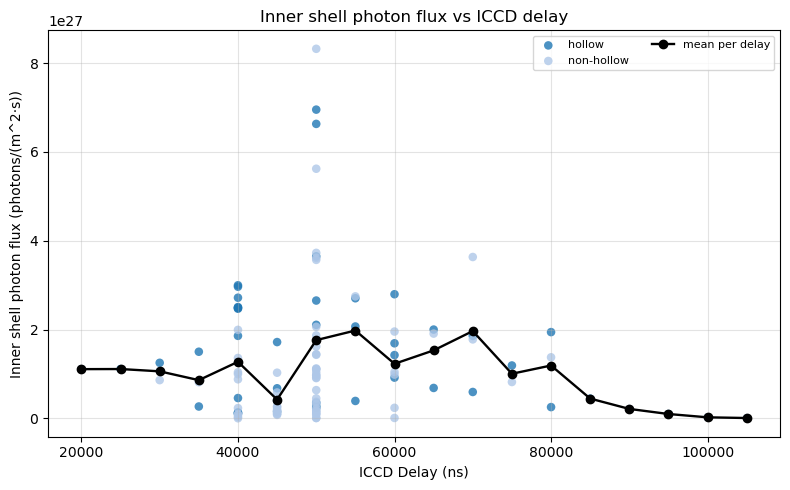

Mean emissivity per delay:
  Delay 20000 ns : mean ε_inner = 1.107e+27
  Delay 25000 ns : mean ε_inner = 1.11e+27
  Delay 30000 ns : mean ε_inner = 1.058e+27
  Delay 35000 ns : mean ε_inner = 8.597e+26
  Delay 40000 ns : mean ε_inner = 1.273e+27
  Delay 45000 ns : mean ε_inner = 4.216e+26
  Delay 50000 ns : mean ε_inner = 1.761e+27
  Delay 55000 ns : mean ε_inner = 1.978e+27
  Delay 60000 ns : mean ε_inner = 1.228e+27
  Delay 65000 ns : mean ε_inner = 1.53e+27
  Delay 70000 ns : mean ε_inner = 1.965e+27
  Delay 75000 ns : mean ε_inner = 1.004e+27
  Delay 80000 ns : mean ε_inner = 1.189e+27
  Delay 85000 ns : mean ε_inner = 4.443e+26
  Delay 90000 ns : mean ε_inner = 2.113e+26
  Delay 95000 ns : mean ε_inner = 9.689e+25
  Delay 100000 ns : mean ε_inner = 2.19e+25
  Delay 105000 ns : mean ε_inner = 6.477e+24


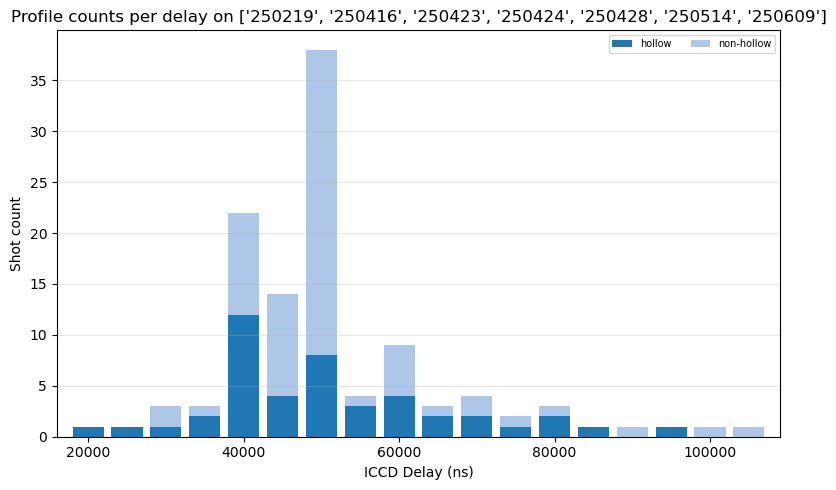

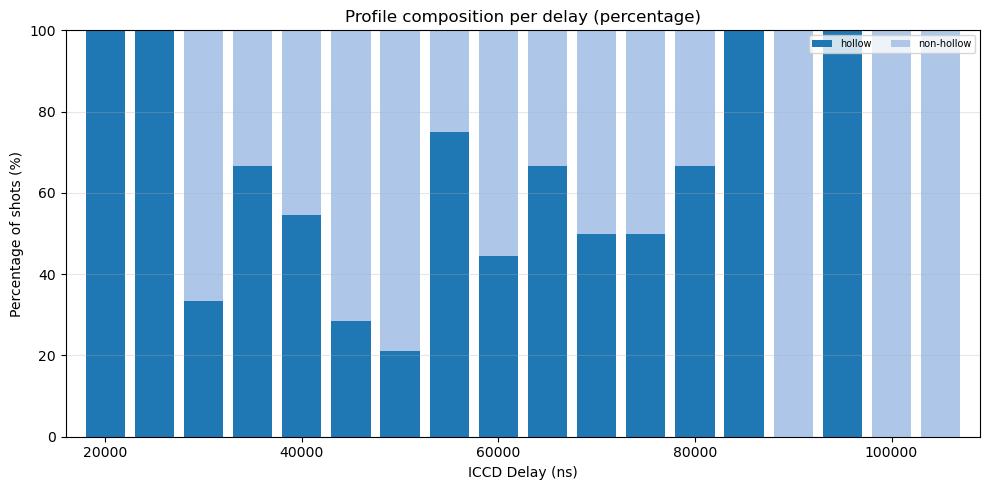

Counts per delay (profile -> count):
Delay 20000 ns:
  hollow: 1
  TOTAL: 1
Delay 25000 ns:
  hollow: 1
  TOTAL: 1
Delay 30000 ns:
  non-hollow: 2
  hollow: 1
  TOTAL: 3
Delay 35000 ns:
  non-hollow: 1
  hollow: 2
  TOTAL: 3
Delay 40000 ns:
  hollow: 12
  non-hollow: 10
  TOTAL: 22
Delay 45000 ns:
  non-hollow: 10
  hollow: 4
  TOTAL: 14
Delay 50000 ns:
  non-hollow: 30
  hollow: 8
  TOTAL: 38
Delay 55000 ns:
  hollow: 3
  non-hollow: 1
  TOTAL: 4
Delay 60000 ns:
  non-hollow: 5
  hollow: 4
  TOTAL: 9
Delay 65000 ns:
  hollow: 2
  non-hollow: 1
  TOTAL: 3
Delay 70000 ns:
  hollow: 2
  non-hollow: 2
  TOTAL: 4
Delay 75000 ns:
  non-hollow: 1
  hollow: 1
  TOTAL: 2
Delay 80000 ns:
  hollow: 2
  non-hollow: 1
  TOTAL: 3
Delay 85000 ns:
  hollow: 1
  TOTAL: 1
Delay 90000 ns:
  non-hollow: 1
  TOTAL: 1
Delay 95000 ns:
  hollow: 1
  TOTAL: 1
Delay 100000 ns:
  non-hollow: 1
  TOTAL: 1
Delay 105000 ns:
  non-hollow: 1
  TOTAL: 1


In [23]:
from pathlib import Path
import h5py, numpy as np, matplotlib.pyplot as plt, csv, ast, re
from collections import defaultdict, Counter

# Manual date filter: list the 6-digit dates you want included
include_dates = ["250219", "250416", "250423", "250424", "250428", "250514", "250609"]
# include_dates = None  # <-- EDIT THIS LIST AS NEEDED
include_set = set(include_dates)
print("Manual date filter active. Including dates:", sorted(include_set))

# Optional profile subset (set to None to include all profiles)
include_profiles = None  # e.g. ["off-center hollow", "flat"]
print("Profile subset:", ("ALL" if include_profiles is None else include_profiles))

MANIFEST = Path("/Users/elyselian/Downloads/Python Code/S_XB/sxb_analysis/curated/manifest.csv")
OUT_H5 = Path("/Users/elyselian/Downloads/Python Code/S_XB/sxb_analysis/curated/experiment.h5")

def parse_float_any(x):
    if x is None:
        return None
    if isinstance(x, (bytes, bytearray)):
        x = x.decode("utf-8", "ignore")
    if hasattr(x, "item"):
        try:
            x = x.item()
        except Exception:
            pass
    if isinstance(x, (int, float)):
        return float(x)
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(x))
    return float(m.group(0)) if m else None

def get_iccd_delay_ns(grp, dset=None):
    exact_names = [
        "Iccd Delay (ns)", "ICCD Delay (ns)", "ICCDDelay (ns)",
        "IccdDelay (ns)", "Delay (ns)", "Delay_ns", "Delay"
    ]
    for name in exact_names:
        v = grp.attrs.get(name, None)
        if v is None and dset is not None:
            v = dset.attrs.get(name, None)
        v = parse_float_any(v)
        if v is not None:
            return v
    def scan(obj):
        for k, v in obj.attrs.items():
            kl = str(k).lower()
            if "delay" in kl and "ns" in kl:
                vv = parse_float_any(v)
                if vv is not None:
                    return vv
        return None
    v = scan(grp)
    if v is None and dset is not None:
        v = scan(dset)
    return v

def get_str_attr(grp, key, default=""):
    v = grp.attrs.get(key, default)
    if isinstance(v, (bytes, bytearray)):
        try:
            return v.decode("utf-8", "ignore")
        except Exception:
            return default
    return str(v) if v is not None else default

# Helper: reusable bar chart function
def plot_profile_histograms_per_delay(delay_int, delays, profs, color_map, title_suffix=""):
    """Draw stacked bars of profile counts per integer delay (absolute and percentage).

    Parameters
    - delay_int: np.ndarray[int], integer-rounded delays for grouping
    - delays: np.ndarray[float], original delay values (used for axis ticks)
    - profs: np.ndarray[str], profile labels per shot
    - color_map: dict profile->color
    - title_suffix: str, optional extra label for titles
    Returns dict mapping delay->Counter(profile->count)
    """
    unique_delays = np.unique(delay_int)
    unique_profiles = np.unique(profs)
    counts_per_delay_profile = {d: Counter(profs[delay_int == d]) for d in unique_delays}
    delay_sorted = sorted(unique_delays)
    profile_sorted = sorted(unique_profiles)

    # Build matrices
    abs_matrix = np.zeros((len(profile_sorted), len(delay_sorted)), dtype=int)
    for j, d in enumerate(delay_sorted):
        c = counts_per_delay_profile[d]
        for i, p in enumerate(profile_sorted):
            abs_matrix[i, j] = c.get(p, 0)

    # Compute a sensible bar width based on spacing
    if len(delay_sorted) > 1:
        diffs = np.diff(delay_sorted)
        width = float(np.min(diffs)) * 0.8
    else:
        width = 4000.0

    # Absolute counts chart
    fig_h, ax_h = plt.subplots(figsize=(8, 5))
    bottom = np.zeros(len(delay_sorted), dtype=int)
    for i, p in enumerate(profile_sorted):
        vals = abs_matrix[i]
        ax_h.bar(delay_sorted, vals, bottom=bottom, label=p, color=color_map.get(p, None), width=width, align='center')
        bottom += vals
    ax_h.set_xlabel('ICCD Delay (ns)')
    ax_h.set_ylabel('Shot count')
    ax_h.set_title(f'Profile counts per delay on {include_dates}')
    ax_h.legend(fontsize=7, ncol=3)
    ax_h.grid(alpha=0.3, axis='y')
    # Expand limits a bit
    ax_h.set_xlim(min(delay_sorted) - width, max(delay_sorted) + width)
    plt.tight_layout()
    plt.show()

    # Percentage chart
    pct_matrix = np.zeros_like(abs_matrix, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        for j in range(len(delay_sorted)):
            col_sum = abs_matrix[:, j].sum()
            if col_sum > 0:
                pct_matrix[:, j] = abs_matrix[:, j] / col_sum * 100.0
    fig_pct, ax_pct = plt.subplots(figsize=(10, 5))
    bottom = np.zeros(len(delay_sorted), dtype=float)
    for i, p in enumerate(profile_sorted):
        vals = pct_matrix[i]
        ax_pct.bar(delay_sorted, vals, bottom=bottom, label=p, color=color_map.get(p, None), width=width, align='center')
        bottom += vals
    ax_pct.set_xlabel('ICCD Delay (ns)')
    ax_pct.set_ylabel('Percentage of shots (%)')
    ttl = 'Profile composition per delay (percentage)'
    if title_suffix:
        ttl += f" — {title_suffix}"
    ax_pct.set_title(ttl)
    ax_pct.set_ylim(0, 100)
    ax_pct.legend(fontsize=7, ncol=3)
    ax_pct.grid(alpha=0.3, axis='y')
    ax_pct.set_xlim(min(delay_sorted) - width, max(delay_sorted) + width)
    plt.tight_layout()
    plt.show()

    return counts_per_delay_profile

# Collect allowed HDF5 group keys from manifest whose date is in include_set
allowed = set()
with MANIFEST.open("r") as f:
    for row in csv.DictReader(f):
        raw = row.get("shot_id", "")
        try:
            shot = ast.literal_eval(raw)
        except Exception:
            shot = raw
        if isinstance(shot, (list, tuple)) and len(shot) >= 1:
            date = str(shot[0])[:6]
            key = "_".join(map(str, shot))
        else:
            s = str(shot)
            m = re.search(r"\d{6}", s)
            date = m.group(0) if m else ""
            key = s.replace(" ", "_")
        if date and date.isdigit() and date in include_set:
            allowed.add(key)

if not allowed:
    print("No shots matched the provided include_dates. Adjust include_dates list.")

# Accumulators for scatter and profile counts
delay_vals = []
inner_eps_vals = []
profiles = []
missing_attr = 0

with h5py.File(OUT_H5, "r") as f:
    shots = f["shots"]
    for key in allowed:
        if key not in shots:
            continue
        grp = shots[key]
        dset = grp.get("image")
        prof = get_str_attr(grp, "profile_shape", "unlabeled")
        if include_profiles is not None and prof not in include_profiles:
            continue
        delay = get_iccd_delay_ns(grp, dset)
        if delay is None:
            continue
        inner_eps = grp.attrs.get("inner_shell_emissivity", None)
        if inner_eps is None:
            missing_attr += 1
            continue
        try:
            inner_eps = float(inner_eps)
        except Exception:
            missing_attr += 1
            continue
        delay_vals.append(float(delay))
        inner_eps_vals.append(inner_eps)
        profiles.append(prof)

print(f"Allowed keys: {len(allowed)}, collected points: {len(delay_vals)}, missing inner_shell_emissivity: {missing_attr}")
print("Profiles present:", dict(Counter(profiles)))

if not delay_vals:
    print("No data to plot (no delays with inner shell emissivity).")
else:
    delays = np.array(delay_vals)
    emiss = np.array(inner_eps_vals, dtype=float)
    profs = np.array(profiles)
    delay_int = np.round(delays).astype(int)
    unique_delays = np.unique(delay_int)
    mean_by_delay = {d: np.mean(emiss[delay_int == d]) for d in unique_delays}

    # Scatter colored by profile
    cmap = plt.get_cmap("tab20")
    unique_profiles = np.unique(profs)
    color_map = {p: cmap(i % 20) for i, p in enumerate(unique_profiles)}

    fig_s, ax_s = plt.subplots(figsize=(8, 5))
    for p in unique_profiles:
        mask = profs == p
        ax_s.scatter(delays[mask], emiss[mask], s=38, alpha=0.8, label=p, color=color_map[p], edgecolors='none')
    xs = sorted(mean_by_delay.keys())
    ys = [mean_by_delay[x] for x in xs]
    ax_s.plot(xs, ys, 'k-o', lw=1.7, ms=6, label='mean per delay')
    ax_s.set_xlabel('ICCD Delay (ns)')
    ax_s.set_ylabel('Inner shell photon flux (photons/(m^2·s))')
    ax_s.set_title('Inner shell photon flux vs ICCD delay') 
    ax_s.grid(alpha=0.35)
    ax_s.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    print("Mean emissivity per delay:")
    for d in xs:
        print(f"  Delay {d:>4d} ns : mean ε_inner = {mean_by_delay[d]:.4g}")

    # Restored bar chart histograms (absolute + percentage)
    counts_per_delay_profile = plot_profile_histograms_per_delay(delay_int, delays, profs, color_map)

    # Print counts summary
    print("Counts per delay (profile -> count):")
    for d in sorted(counts_per_delay_profile.keys()):
        print(f"Delay {d:>4d} ns:")
        for p, cnt in counts_per_delay_profile[d].items():
            print(f"  {p}: {cnt}")
        print(f"  TOTAL: {sum(counts_per_delay_profile[d].values())}")